In [ ]:
import numpy as np
import matplotlib
#matplotlib.use("Agg")  # remove/comment out if running interactively and want plt.show()
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import util, image_util
import lenstronomy.Util.simulation_util as sim_util

In [25]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

background_rms = .005  #  background noise per pixel
exp_time = 1000.  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 120  #  cutout pixel size per axis
deltaPix = 0.05  #  pixel size in arcsec (area per pixel = pixel_scale**2)
fwhm = 0.05  # full width at half maximum of PSF
psf_type = 'GAUSSIAN'

In [26]:
#define redshifts
zl = 0.222
zs1 = 0.609
zs2 = 2.025

In [41]:
#define galaxy kwargs

#lens mass
l_sie_kwargs = {'theta_E': .66, 'center_x': 0.05, 'center_y': 0, 'e1': .07, 'e2': -0.03}
l_shear_kwargs = {'gamma1': 0.0, 'gamma2': -0.05}
#lens light
l_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}]


#s1 mass
s1_sie_kwargs = {'theta_E': 0.03, 'center_x': 0.10, 'center_y': 0.00, 'e1': -0.10, 'e2': 0.10}
#s1_shear_kwargs = ...
#s1 light
s1_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}]


#s2 light
s2_sersic_kwargs = [{'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}]

In [28]:
#light model class
l_light_model = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

s1_light_model  = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

s2_light_model = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

In [29]:
#lens model 

#this is to model s1 light getting lensed by the lens
s1_lens_model = LensModel(
    lens_model_list=['SIE', 'SHEAR'],
    lens_redshift_list=[zl, zl],
    z_source=zs1,
    multi_plane=True,
    cosmo=cosmo
)

l_s1_kwargs = [l_sie_kwargs, l_shear_kwargs]


#this is to model how s2 light getting lensed twice
s2_lens_model = LensModel(
    lens_model_list=['SIE', 'SHEAR', 'SIE'], #can add shear of s1
    lens_redshift_list=[zl, zl, zs1],
    z_source=zs2,
    multi_plane=True,
    cosmo=cosmo
)

l_s1_s2_kwargs = [l_sie_kwargs, l_shear_kwargs, s1_sie_kwargs]

In [30]:
kwargs_data = sim_util.data_configure_simple(
    numPix,
    deltaPix,
    exposure_time=exp_time,
    background_rms=background_rms,
)
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': deltaPix, 'truncation': 3}
kwargs_numerics = {"supersampling_factor": 2}

data_class = ImageData(**kwargs_data)
psf_class = PSF(**kwargs_psf)

In [46]:
#2 image models
#s1
s1_image_model = ImageModel(
    data_class=data_class,
    psf_class=psf_class,
    lens_model_class=s1_lens_model,
    lens_light_model_class=l_light_model,
    source_model_class=s1_light_model,
    kwargs_numerics=kwargs_numerics
)

#s2
s2_image_model = ImageModel(
    data_class=data_class,
    psf_class=psf_class,
    lens_model_class=s2_lens_model,
    lens_light_model_class=None,
    source_model_class=s2_light_model,
    kwargs_numerics=kwargs_numerics
)

In [47]:
s1_image = s1_image_model.image(
    kwargs_lens=l_s1_kwargs,
    kwargs_source=s1_sersic_kwargs,
    kwargs_lens_light=l_sersic_kwargs
)

s2_image = s2_image_model.image(
    kwargs_lens=l_s1_s2_kwargs,
    kwargs_source=s2_sersic_kwargs,
    kwargs_lens_light=None
)

image = s1_image + s2_image

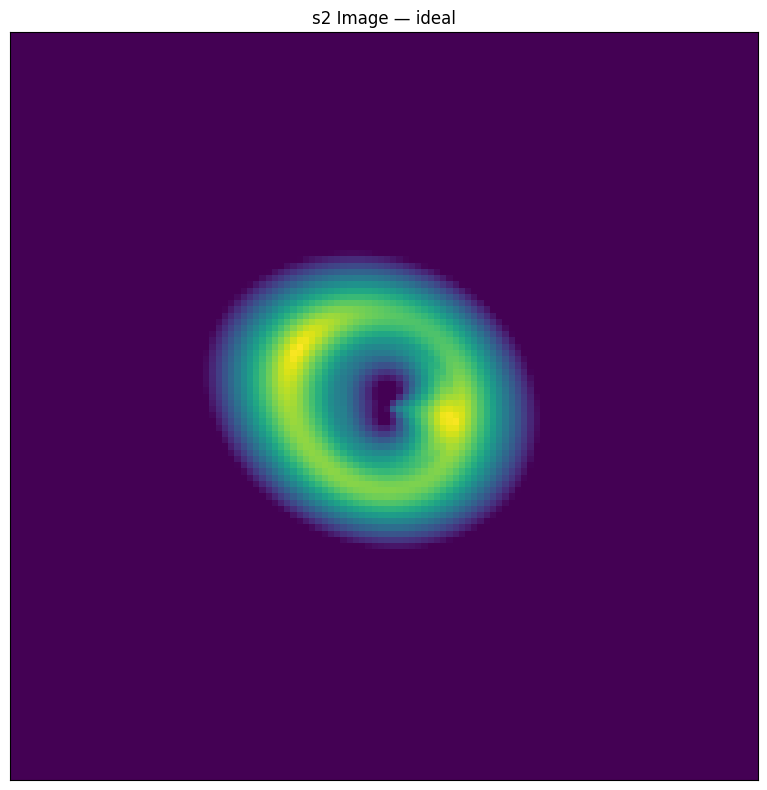

In [68]:
#test cell

x_grid, y_grid = util.make_grid(
    numPix=numPix,
    deltapix=deltaPix,
)

beta_x1, beta_y1 = s1_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_kwargs
)

beta_x2, beta_y2 = s2_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

alpha_x1, alpha_y1 = s1_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_kwargs
)

alpha_x2, alpha_y2 = s2_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

x_grid_2d = x_grid.reshape((numPix, numPix))
y_grid_2d = y_grid.reshape((numPix, numPix))

beta_x1_2d = beta_x1.reshape((numPix, numPix))
beta_y1_2d = beta_y1.reshape((numPix, numPix))

beta_x2_2d = beta_x2.reshape((numPix, numPix))
beta_y2_2d = beta_y2.reshape((numPix, numPix))

alpha_x1_2d = alpha_x1.reshape((numPix, numPix))
alpha_y1_2d = alpha_y1.reshape((numPix, numPix))

alpha_x2_2d = alpha_x2.reshape((numPix, numPix))
alpha_y2_2d = alpha_y2.reshape((numPix, numPix))


fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    np.log10(
        np.clip(s2_image, 1e-6, None)
    ),
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "s2 Image — ideal"
)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()

plt.show()

In [48]:
poisson_noise = image_util.add_poisson(
    image,
    exp_time=exp_time,
)

background_noise = image_util.add_background(
    image,
    sigma_bkd=background_rms,
)

image_noisy = (image + poisson_noise + background_noise)

In [ ]:
x_grid, y_grid = util.make_grid(
    numPix=numPix,
    deltapix=deltaPix,
)

beta_x1, beta_y1 = s1_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_kwargs
)

beta_x2, beta_y2 = s2_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

alpha_x1, alpha_y1 = s1_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_kwargs
)

alpha_x2, alpha_y2 = s2_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

In [55]:
x_grid_2d = x_grid.reshape((numPix, numPix))
y_grid_2d = y_grid.reshape((numPix, numPix))

beta_x1_2d = beta_x1.reshape((numPix, numPix))
beta_y1_2d = beta_y1.reshape((numPix, numPix))

beta_x2_2d = beta_x2.reshape((numPix, numPix))
beta_y2_2d = beta_y2.reshape((numPix, numPix))

alpha_x1_2d = alpha_x1.reshape((numPix, numPix))
alpha_y1_2d = alpha_y1.reshape((numPix, numPix))

alpha_x2_2d = alpha_x2.reshape((numPix, numPix))
alpha_y2_2d = alpha_y2.reshape((numPix, numPix))


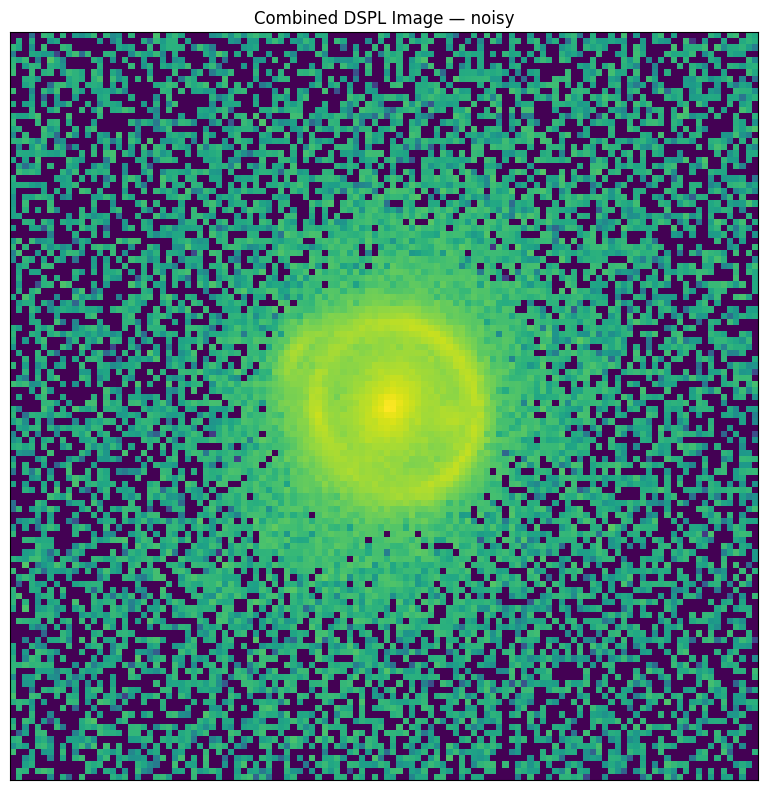

In [62]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    np.log10(
        np.clip(image_noisy, 1e-6, None)
    ),
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "Combined DSPL Image — noisy"
)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()

plt.show()


In [ ]:
'''
#setting up the lens galaxy
#mass profile
l_model_list = ['SIE', 'SHEAR', 'SIE']
l_kwargs_sie = {'theta_E': .66, 'center_x': 0.05, 'center_y': 0, 'e1': .07, 'e2': -0.03}
l_kwargs_shear = {'gamma1': 0.0, 'gamma2': -0.05}  # shear values to the source plane
s1_kwargs_sie = {'theta_E': 0.03, 'center_x': 0.10, 'center_y': 0.00, 'e1': -0.10, 'e2': 0.10}

kwargs_lens = [l_kwargs_sie, l_kwargs_shear, s1_kwargs_sie]

redshift_list = [zl, zl, zs1]

l_model_class = LensModel(
    l_model_list,
    lens_redshift_list=redshift_list,
    z_source=zs2,
    cosmo=cosmo,
    multi_plane=True
    )

#light profile source
source_list = ['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE']
s1_kwargs = {'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}
s2_kwargs = {'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}

kwargs_source = [s1_kwargs, s2_kwargs]
source_model_class = LightModel(
    source_list,
    source_redshift_list=[zs1, zs2]
    )

#light profile lens
l_lens_list = ["SERSIC_ELLIPSE"]
l_kwargs_lens = {'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}
kwargs_lens_light = [l_kwargs_lens]
lens_light_model_class = LightModel(l_lens_list)
'''

In [ ]:
'''
_, _, ra_at_xy_0, dec_at_xy_0, _, _, Mpix2coord, _ = util.make_grid_with_coordtransform(numPix=numPix, deltapix=pixel_scale, center_ra=0, center_dec=0, subgrid_res=1, inverse=False)
kwargs_data = {'background_rms': background_rms,  # rms of background noise
               'exposure_time': exp_time,  # exposure time (or a map per pixel)
               'ra_at_xy_0': ra_at_xy_0,  # RA at (0,0) pixel
               'dec_at_xy_0': dec_at_xy_0,  # DEC at (0,0) pixel 
               'transform_pix2angle': Mpix2coord,  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
               'image_data': np.zeros((numPix, numPix))  # 2d data vector, here initialized with zeros as place holders that get's overwritten once a simulated image with noise is created.
              }

kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': pixel_scale, 'truncation': 3}
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

data_class = ImageData(**kwargs_data)
psf_class = PSF(**kwargs_psf)

imageModel = ImageModel(data_class, psf_class, lens_model_class=l_model_class, 
                        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                        kwargs_numerics=kwargs_numerics)

image_model = imageModel.image(kwargs_lens, kwargs_source, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None)

poisson = image_util.add_poisson(image_model, exp_time=exp_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

data_class.update_data(image_real)
kwargs_data['image_data'] = image_real
'''

In [ ]:
'''
psf_class = PSF(**kwargs_psf)

imageModel = ImageModel(data_class, psf_class, lens_model_class=l_model_class, 
                        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                        kwargs_numerics=kwargs_numerics)

image_model = imageModel.image(kwargs_lens, kwargs_source, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None)

poisson = image_util.add_poisson(image_model, exp_time=exp_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

data_class.update_data(image_real)
kwargs_data['image_data'] = image_real
'''

/var/folders/_n/r_6tbbrn3jd1nn364_ty0xnm0000gn/T/ipykernel_10380/2090643262.py:11: RuntimeWarning: invalid value encountered in log10
  im = ax.matshow(np.log10(image_real), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])


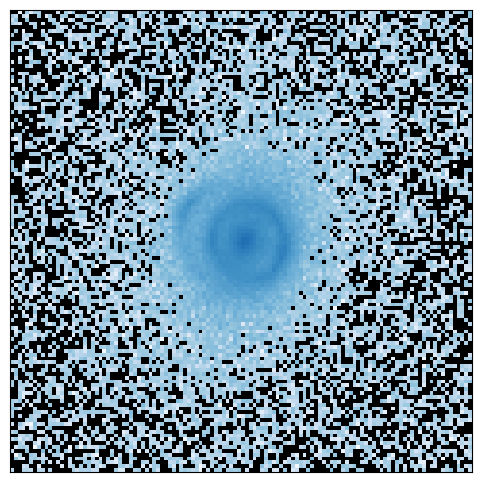

In [ ]:
'''
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad(color='k', alpha=1.)
cmap.set_under('k')

v_min = -4
v_max = 1

f, axes = plt.subplots(1, 1, figsize=(6, 6), sharex=False, sharey=False)

ax = axes
im = ax.matshow(np.log10(image_real), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.autoscale(False)

plt.show()
'''

In [25]:
x = np.arange(0, 10, 100)
y = x*23

plt.plot(x, y)
plt.show()

/var/folders/_n/r_6tbbrn3jd1nn364_ty0xnm0000gn/T/ipykernel_2921/3173012881.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
